In [ ]:
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm
from pathlib import Path
import warnings
import copy
import csv

from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

np.random.seed(42)
torch.manual_seed(42)
device = "cuda" if torch.cuda.is_available() else "cpu"

# Paths
ROOT = Path("Amazon_products")
TRAIN_CORPUS_PATH = ROOT / "train" / "train_corpus.txt"
TEST_CORPUS_PATH  = ROOT / "test" / "test_corpus.txt"
CLASS_PATH = ROOT / "classes.txt"

EMB_DIR = Path("SilverGeneration/EmbeddingsRemake")
X_ALL_PATH = EMB_DIR / "X_train_test_mpnet.pt" # Train + Test embeddings
LABEL_EMB_PATH = EMB_DIR / "labels_base_mpnet.pt" #test base

MODEL_SAVE = Path("Models")
MODEL_SAVE.mkdir(exist_ok=True)
MODEL_PATH = MODEL_SAVE / "GNN.pt"

# Load useful data (like silver gen)
def load_classic(path):
    id2text = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            pid, text = line.strip().split("\t", 1)
            id2text[int(pid)] = text
    return id2text

id2text_train = load_classic(TRAIN_CORPUS_PATH)
id2text_test  = load_classic(TEST_CORPUS_PATH)
train_ids = list(id2text_train.keys())
test_ids  = list(id2text_test.keys())
print(test_ids)
n_train = len(train_ids)
n_test  = len(test_ids)
test_ids  = [n_train + i for i in range(n_test)]
print(test_ids)
print(f"Train IDs: {n_train} | Test IDs: {n_test}")

all_ids = train_ids + test_ids
print(len(set(all_ids)))

# To test : silver_train_all, silver_train_all, silver_train_bm25, silver_train_classic, silver_train_mixed, silver_train_mpnet_nohier, silver_train_mpnet
with open("SilverGeneration/SilverCombo/pseudo_silver_all_Remake.json", "r", encoding="utf-8") as f:
    raw = json.load(f)
silver_labels = {int(pid): data["labels"] for pid, data in raw.items()}
silver_scores = {int(pid): data["scores"] for pid, data in raw.items()}

print(len(silver_labels))

with open("SilverGeneration/SilverCombo/pseudo_gold_all_Remake.json", "r", encoding="utf-8") as f:
    raw = json.load(f)
gold_labels = {int(pid): data["labels"] for pid, data in raw.items()}
gold_scores = {int(pid): data["scores"] for pid, data in raw.items()}

gold_ids = set(gold_labels.keys())
silver_labels = {pid: labels for pid, labels in silver_labels.items() if pid not in gold_ids}
silver_scores = {pid: scores for pid, scores in silver_scores.items() if pid not in gold_ids}

print(f"{len(silver_labels)}")
print(f"{len(gold_labels)}")

# Load X_all + split into X_train & X_test
data = torch.load(X_ALL_PATH, weights_only=False)

# ensure tensor (check)
if isinstance(data, np.ndarray):
    data = torch.from_numpy(data)
elif isinstance(data, list):
    data = torch.stack(data)

X_all = data.float().to(device)

# Load Class names
classes = {}
with open(CLASS_PATH, "r", encoding="utf-8") as f:
    for line in f:
        cid, cname = line.strip().split("\t")
        classes[int(cid)] = cname

n_classes = len(classes) # 531
print(n_classes)

pid2idx = {pid: i for i, pid in enumerate(all_ids)}


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [2]:
class MultiLabelDataset(Dataset):
    def __init__(self, pids, labels_dict, scores_dict, n_classes):
        self.pids = pids
        self.labels_dict = labels_dict
        self.scores_dict = scores_dict
        self.n_classes = n_classes

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]

        # Embedding global
        emb = X_all[pid2idx[pid]]

        # Multi-hot vector with soft scores
        y = torch.zeros(self.n_classes)
        labels = self.labels_dict[pid]
        scores = self.scores_dict[pid]

        for c, s in zip(labels, scores):
            y[c] = float(s)

        return {"pid": pid,"X": emb,"y": y}


In [3]:
# TRAIN / VAL splits
gold_ids = list(gold_labels.keys())
silver_ids = list(silver_labels.keys())

# Split gold: 33% validation, 67% train
gold_train, gold_val = train_test_split(gold_ids, test_size=0.5, random_state=42)

# Train = 67% gold + silver
train_p = gold_train + silver_ids
val_p = gold_val

print(f"Train: {len(train_p)} examples ({len(gold_train)} gold + {len(silver_ids)} silver)")
print(f"Val: {len(val_p)} examples (gold)")

X_train_split = torch.stack([X_all[pid2idx[pid]] for pid in train_p])
X_val_split = torch.stack([X_all[pid2idx[pid]] for pid in val_p])

train_labels = {}
for pid in gold_train:
    train_labels[pid] = gold_labels[pid]
for pid in silver_labels:
    train_labels[pid] = silver_labels[pid]

train_scores = {}
for pid in gold_train:
    train_scores[pid] = gold_scores[pid]
for pid in silver_labels:
    train_scores[pid] = silver_scores[pid]

train_dataset = MultiLabelDataset(train_p, train_labels, train_scores, n_classes)
val_dataset = MultiLabelDataset(val_p, gold_labels, gold_scores, n_classes)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

"""print("\nChecking alignment consistency...")
pid0 = train_p[0]
print("train_p[0] =", pid0)
print("pid2idx[pid0] =", pid2idx[pid0])

print("Embedding from X_all :",
      X_all[pid2idx[pid0]][:5].cpu().numpy())

print("Embedding from X_train_split :",
      X_train_split[0][:5].cpu().numpy())"""


Train: 29066 examples (5591 gold + 23475 silver)
Val: 5591 examples (gold)


'print("\nChecking alignment consistency...")\npid0 = train_p[0]\nprint("train_p[0] =", pid0)\nprint("pid2idx[pid0] =", pid2idx[pid0])\n\nprint("Embedding from X_all :",\n      X_all[pid2idx[pid0]][:5].cpu().numpy())\n\nprint("Embedding from X_train_split :",\n      X_train_split[0][:5].cpu().numpy())'

In [4]:
class LabelGCNClassic(nn.Module):
    def __init__(self, emb_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.dropout = dropout

        self.W_list = nn.ParameterList([
            nn.Parameter(torch.empty(emb_dim, emb_dim)) 
            for i in range(num_layers)
        ])

        for W in self.W_list:
            nn.init.xavier_uniform_(W)

    def forward(self, H, A_hat):
        for i, W in enumerate(self.W_list):
            H = A_hat @ H @ W

            if i < len(self.W_list) - 1:
                H = F.relu(H)
                H = F.dropout(H, p=self.dropout, training=self.training)

        return H


class GCNEnhancedClassifierClassic(nn.Module):
    def __init__(self, input_dim, label_init_emb, A_hat, parents_map=None, num_layers=1, dropout=0.3, scale=25):
        super().__init__()
        self.dropout = dropout
        self.parents_map = parents_map if parents_map is not None else {}
        self.scale = scale

        emb_dim = label_init_emb.size(1)

        # document encoder
        self.proj = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.ReLU(inplace=True)
        )
        
        # label encoder
        self.encoder = LabelGCNClassic(emb_dim, num_layers=num_layers, dropout=dropout)

        # learnable label embeddings
        self.label_emb = nn.Parameter(label_init_emb.clone())

        # adjacency fixed
        self.register_buffer("A_hat", A_hat)

    def forward(self, x, return_label_emb=False):
        # refine label embeddings via GCN
        E_refine = self.encoder(self.label_emb, self.A_hat)

        # project document
        x_proj = self.proj(x)
        x_proj = F.dropout(x_proj, p=self.dropout, training=self.training)

        # normalized cosine classifier
        x_norm = F.normalize(x_proj, dim=1)
        E_norm = F.normalize(E_refine, dim=1)
        logits = (x_norm @ E_norm.T) * self.scale

        if return_label_emb:
            return logits, E_refine

        return logits

In [5]:
class LabelGCNUpgrade(nn.Module):
    def __init__(self, emb_dim, num_layers=2, dropout=0.3, alpha=0.5, learn_alpha=False):
        super().__init__()
        self.dropout = dropout
        
        self.W_list = nn.ParameterList([
            nn.Parameter(torch.empty(emb_dim, emb_dim))
            for _ in range(num_layers)
        ])
        for W in self.W_list:
            nn.init.xavier_uniform_(W)

        if learn_alpha:
            self.alpha = nn.Parameter(torch.tensor(alpha))
        else:
            self.register_buffer("alpha", torch.tensor(alpha))

    def forward(self, H, A_hat):
        for i, W in enumerate(self.W_list):

            H_in = H
            H_msg = A_hat @ H_in @ W

            # SKIP CONNECTION
            H = H_in + self.alpha * H_msg

            if i < len(self.W_list) - 1:
                H = F.relu(H)
                H = F.dropout(H, p=self.dropout, training=self.training)

        return H


class GCNEnhancedClassifierUpgrade(nn.Module):
    def __init__(self, input_dim, label_init_emb, A_hat, parents_map=None,
                 num_layers=2, dropout=0.3, scale=25):
        super().__init__()
        self.dropout = dropout
        self.parents_map = parents_map if parents_map is not None else {}
        self.scale = scale

        emb_dim = label_init_emb.size(1)

        # --- PRE-PROCESSING MLP
        self.pre_mlp = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(emb_dim, emb_dim)
        )
        self.encoder = LabelGCNUpgrade(
            emb_dim, num_layers=num_layers, dropout=dropout, alpha=0.5
        )
        self.proj = nn.Linear(input_dim, emb_dim)

        self.label_emb = nn.Parameter(label_init_emb.clone())
        self.register_buffer("A_hat", A_hat)

    def forward(self, x, return_label_emb=False):
        H0 = self.pre_mlp(self.label_emb)
        E_refine = self.encoder(H0, self.A_hat)
        x_proj = self.proj(x)

        x_norm = F.normalize(x_proj, dim=1)
        E_norm = F.normalize(E_refine, dim=1)

        logits = (x_norm @ E_norm.T) * self.scale

        if return_label_emb:
            return logits, E_refine

        return logits


In [6]:
def build_adj_from_hierarchy(class2children, n_classes, w_parent=1.0):
    A = torch.zeros((n_classes, n_classes))

    for parent, children in class2children.items():
        for c in children:
            if parent < n_classes and c < n_classes:
                A[parent, c] = 1.0
                A[c, parent] = 0.5

    A += torch.eye(n_classes)
    D = A.sum(dim=1)
    D_inv_sqrt = torch.pow(D, -0.5)
    D_inv_sqrt[torch.isinf(D_inv_sqrt)] = 0
    D_mat = torch.diag(D_inv_sqrt)

    return D_mat @ A @ D_mat

def load_multilabel(path):
    id2labels = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p, c = map(int, line.strip().split("\t"))
            id2labels.setdefault(p, []).append(c)
    return id2labels

CLASS_HIERARCHY_PATH = ROOT / "class_hierarchy.txt"
class2hierarchy = load_multilabel(CLASS_HIERARCHY_PATH)

A_hat = build_adj_from_hierarchy(class2hierarchy, n_classes).to(device)
print("A_hat:", A_hat.shape, "Non-zero =", (A_hat > 0).sum().item())

label_emb = torch.load(LABEL_EMB_PATH).float().to(device)
print("Label embeddings:", label_emb.shape)

parents_map = {i: [] for i in range(n_classes)}

with open(CLASS_HIERARCHY_PATH, "r") as f:
    for line in f:
        p, c = map(int, line.strip().split("\t"))
        parents_map[c].append(p)  
print("Parents of 1:", parents_map[1])
print(A_hat)

A_hat: torch.Size([531, 531]) Non-zero = 1667
Label embeddings: torch.Size([531, 768])
Parents of 1: [0]
tensor([[0.0588, 0.0832, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0416, 0.1176, 0.2801,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.1400, 0.6667,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.6667, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.6667, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.6667]],
       device='cuda:0')


In [7]:
# Helpers
def is_chain(predicted_labels, parents_map):
    """
    predicted_labels : set/list of predicted class IDs
    parents_map : dict {child -> [parents]}
    
    Returns True if all predicted labels form a single hierarchical chain.
    """
    labels = list(predicted_labels)
    n = len(labels)
    if n <= 1:
        return True

    for i in range(n):
        for j in range(i+1, n):
            a, b = labels[i], labels[j]

            # relation directe ou indirecte
            if not (is_ancestor(a, b, parents_map) or is_ancestor(b, a, parents_map)):
                return False

    return True

def is_ancestor(parent, child, parents_map):
    stack = [child]
    visited = set()

    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)

        for p in parents_map.get(node, []):
            if p == parent:
                return True
            stack.append(p)

    return False


def hierarchy_chain_consistency_from_probs(model, loader, parents_map):
    model.eval()
    total = 0
    valid = 0

    with torch.no_grad():
        for batch in loader:
            X = batch["X"].to(device)
            logits = model(X)
            probs = torch.sigmoid(logits).cpu().numpy()

            for p in probs:
                idx = np.argsort(p)[::-1]
                top3 = idx[:3]
                if p[top3[2]] < 0.5 * p[top3[1]]:
                    labels = {int(top3[0]), int(top3[1])}
                else:
                    labels = {int(top3[0]), int(top3[1]), int(top3[2])}

                total += 1
                if is_chain(labels, parents_map):
                    valid += 1

    return valid / total

In [8]:
# Evaluation metrics -> see paper given
def precision_at_1(y_true, scores):
    correct = 0
    for yt, sc in zip(y_true, scores):
        top1 = sc.argmax()
        if yt[top1] == 1:
            correct += 1
    return correct / len(y_true)


def precision_at_3(y_true, scores):
    total_correct = 0
    for yt, sc in zip(y_true, scores):
        top3 = sc.argsort()[-3:][::-1]
        total_correct += yt[top3].sum()
    return total_correct / (3 * len(y_true))

def evaluate_topk_full(model, loader, k=3):
    model.eval()
    
    all_scores = []
    all_true = []
    preds_bin = []

    with torch.no_grad():
        for batch in loader:
            X = batch["X"].to(device)
            y = batch["y"].cpu().numpy()         

            y_bin = (y > 0).astype(int)         

            logits = model(X)
            prob = torch.sigmoid(logits).cpu().numpy()

            all_scores.extend(prob)
            all_true.extend(y_bin)              

            # --- TOP-K prediction ---
            topk_idx = np.argsort(-prob, axis=1)[:, :k]
            pred_bin = np.zeros_like(prob, dtype=int)

            for i in range(prob.shape[0]):
                pred_bin[i, topk_idx[i]] = 1

            preds_bin.extend(pred_bin)

    preds_bin = np.array(preds_bin)
    all_true = np.array(all_true)
    all_scores = np.array(all_scores)

    f1s = f1_score(all_true, preds_bin, average="samples")
    f1m = f1_score(all_true, preds_bin, average="macro")
    p1 = precision_at_1(all_true, all_scores)
    p3 = precision_at_3(all_true, all_scores)

    return f1s, f1m, p1, p3


In [9]:
configs = []

dropouts = [0.2, 0.4]
scales = [25, 40]
num_layers = [1, 2]
model_families = {
    "classic": GCNEnhancedClassifierClassic,
}

# Build all configurations
for model_name, model_class in model_families.items():
    for dp in dropouts:
        for sc in scales:
            for num_layer in num_layers:
                configs.append({
                    "model_name": model_name,
                    "dropout": dp,
                    "scale": sc,
                    "num": num_layer,
                })

print("Total configs:", len(configs))

Total configs: 8


In [10]:
"""for cfg in configs:

    tag = f"{cfg['model_name']}_dp{cfg['dropout']}_sc{cfg['scale']}_n{cfg['num']}"
    print("config:", tag)

    # Build model
    model = model_families[cfg["model_name"]](
        input_dim=X_all.size(1),
        label_init_emb=label_emb,
        A_hat=A_hat,
        parents_map=parents_map,
        num_layers=cfg["num"],
        dropout=cfg["dropout"],
        scale=cfg["scale"]
    ).to(device)
"""

'for cfg in configs:\n\n    tag = f"{cfg[\'model_name\']}_dp{cfg[\'dropout\']}_sc{cfg[\'scale\']}_n{cfg[\'num\']}"\n    print("config:", tag)\n\n    # Build model\n    model = model_families[cfg["model_name"]](\n        input_dim=X_all.size(1),\n        label_init_emb=label_emb,\n        A_hat=A_hat,\n        parents_map=parents_map,\n        num_layers=cfg["num"],\n        dropout=cfg["dropout"],\n        scale=cfg["scale"]\n    ).to(device)\n'

In [11]:
"""# Classic training without techniques of regularization only early stopping and bestf1 improvement
results = {
    "F1s": {},
    "F1m": {},
    "P@1": {},
    "P@3": {},
    "Hierarchy": {}
}

models_states = {}

for cfg in configs:

    tag = f"{cfg['model_name']}_dp{cfg['dropout']}_sc{cfg['scale']}_n{cfg['num']}"
    print("config:", tag)

    # Build model
    model = model_families[cfg["model_name"]](
        input_dim=X_all.size(1),
        label_init_emb=label_emb,
        A_hat=A_hat,
        parents_map=parents_map,
        num_layers=cfg["num"],
        dropout=cfg["dropout"],
        scale=cfg["scale"]
    ).to(device)

    # Optimizer
    optimizer = torch.optim.Adam([
        {"params": model.proj.parameters(), "lr": 1e-3},
        {"params": model.encoder.parameters(), "lr": 2e-4},
        {"params": model.label_emb, "lr": 2e-4},
    ])
    best_f1m = 0
    best_state = None
    wait = 0
    patience = 5
    epochs = 30

    f1s_curve, f1m_curve, p1_curve, p3_curve = [], [], [], []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            X = batch["X"].to(device)
            y = batch["y"].to(device)

            logits = model(X)
            loss = F.binary_cross_entropy_with_logits(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        model.eval()
        f1s, f1m, p1, p3 = evaluate_topk_full(model, val_loader)
        f1s_curve.append(f1s)
        f1m_curve.append(f1m)
        p1_curve.append(p1)
        p3_curve.append(p3)

        print(f"[{tag}] Epoch {epoch} | loss={avg_loss:.4f} | F1m={f1m:.4f}")

        if f1m > best_f1m:
            best_f1m = f1m
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print("Early stopping.")
            break

    # SAVE CURVES
    results["F1s"][tag] = f1s_curve
    results["F1m"][tag] = f1m_curve
    results["P@1"][tag] = p1_curve
    results["P@3"][tag] = p3_curve
    models_states[tag] = best_state

    model.load_state_dict(best_state)
    hcc = hierarchy_chain_consistency_from_probs(model, val_loader, parents_map)
    results["Hierarchy"][tag] = hcc

    print(f"FINAL Result : F1m={best_f1m:.4f} | HCC={hcc:.4f}")"""

'# Classic training without techniques of regularization only early stopping and bestf1 improvement\nresults = {\n    "F1s": {},\n    "F1m": {},\n    "P@1": {},\n    "P@3": {},\n    "Hierarchy": {}\n}\n\nmodels_states = {}\n\nfor cfg in configs:\n\n    tag = f"{cfg[\'model_name\']}_dp{cfg[\'dropout\']}_sc{cfg[\'scale\']}_n{cfg[\'num\']}"\n    print("config:", tag)\n\n    # Build model\n    model = model_families[cfg["model_name"]](\n        input_dim=X_all.size(1),\n        label_init_emb=label_emb,\n        A_hat=A_hat,\n        parents_map=parents_map,\n        num_layers=cfg["num"],\n        dropout=cfg["dropout"],\n        scale=cfg["scale"]\n    ).to(device)\n\n    # Optimizer\n    optimizer = torch.optim.Adam([\n        {"params": model.proj.parameters(), "lr": 1e-3},\n        {"params": model.encoder.parameters(), "lr": 2e-4},\n        {"params": model.label_emb, "lr": 2e-4},\n    ])\n    best_f1m = 0\n    best_state = None\n    wait = 0\n    patience = 5\n    epochs = 30\n\n   

In [ ]:
def asymmetric_loss(logits, targets, gamma_pos=0, gamma_neg=4, clip=0.05):
    probs = torch.sigmoid(logits)

    if clip:
        probs_neg = (probs - clip).clamp(min=0)
    else:
        probs_neg = probs

    pos_loss = targets * torch.log(probs + 1e-8) * (1 - probs)**gamma_pos
    neg_loss = (1 - targets) * torch.log(1 - probs_neg + 1e-8) * (probs_neg)**gamma_neg
    return -(pos_loss + neg_loss).mean()


def hierarchical_parent_loss_fast(logits, parent_idx, child_idx, alpha=1.0):
    """
    Force: p[parent] >= 0.8 * p[child]
    """
    probs = torch.sigmoid(logits) 
    
    p = probs[:, parent_idx]        
    c = probs[:, child_idx]       

    # Parent doit être >= 80% du child
    penalty = F.relu(0.8 * c - p)

    return alpha * penalty.mean()

hier_pairs = []
for child, parents in parents_map.items():
    for p in parents:
        hier_pairs.append((p, child))


def soft_f1_loss(logits, targets, eps=1e-8):
    probs = torch.sigmoid(logits)
    tp = (probs * targets).sum(dim=0)
    fp = (probs * (1 - targets)).sum(dim=0)
    fn = ((1 - probs) * targets).sum(dim=0)
    soft_f1 = (2*tp + eps) / (2*tp + fp + fn + eps)
    return 1 - soft_f1.mean()

hier_pairs = []
for child, parents in parents_map.items():
    for p in parents:
        hier_pairs.append((p, child))

parent_idx = torch.tensor([p for p, c in hier_pairs], device=device)
child_idx  = torch.tensor([c for p, c in hier_pairs], device=device)
print(parent_idx)

loss_table = {

    "bce_parent": lambda logits, y:
    F.binary_cross_entropy_with_logits(logits, y) +
    hierarchical_parent_loss_fast(logits, parent_idx, child_idx, alpha=0.2),

    "bce": lambda logits, y:
        F.binary_cross_entropy_with_logits(logits, y),

    "bce_asl": lambda logits, y:
        F.binary_cross_entropy_with_logits(logits, y) +
        0.3 * asymmetric_loss(logits, y),
}

tensor([  0,   1,   3,   3,   5,   4,   0,   8,  10,  11,   3,  13,   3,  15,
          3,  17,   4,  13,   3,  21,  23,  24,  23,  26,   3,  28,   3,  23,
         31,  21,   3,   3,  35,  13,  23,  38,  40,  41,  24,  10, 145,  11,
         44,  34,  24,  21,  24,   3,   3,  51,   3,  10,  54,  15,  17,   5,
         17,  24,  10,  60,  24,  38,  10,  64,  30,  11,  44,  53,  11,  44,
          4,  24,  38,  44,  44,  23,  74,  23,  31,  38,  64,  64,  30,  38,
         54,  74,   3,  85,  38,  38,  26,  64,  38,  60,  64,  38,  54,  31,
          5,  38,  53,  40, 100,  21,  38,  30,  23, 105,  38,  21,  11,  53,
          3, 111,  28, 111,  21,  34,  30,  74, 111,   3, 120,  13, 111,  21,
        111,  21,  21,  40, 128, 128,  40, 131,   5, 131,  40, 135,  38, 135,
         40, 139, 135, 131,  34,  15,  40, 145,   3, 147,  41,  13,  40, 151,
        139,  21, 139, 147, 120,  85, 131,  40, 111,  40, 162,  21,  74,  15,
        151, 160, 147,  17, 169, 170, 199,  21,  44,  54,   4, 1

In [13]:
def dynamic_smoothing(epoch, max_epoch, base=0.1, end=0.01):
    t = epoch / max_epoch
    return base * (1 - t) + end * t

In [14]:
drop_prob = 0.05
freeze_epochs = 10

model = GCNEnhancedClassifierUpgrade(
    input_dim=X_all.size(1),
    label_init_emb=label_emb,
    A_hat=A_hat,
    parents_map=parents_map,
    num_layers=2,
    dropout=0.2,
    scale=40
).to(device)

optimizer = torch.optim.Adam([
    {"params": model.proj.parameters(), "lr": 1e-3},
    {"params": model.encoder.parameters(), "lr": 2e-4},
    {"params": model.label_emb, "lr": 2e-4}
])

best_f1 = 0
best_state = None
wait = 0
patience = 5
epochs = 50

f1_curve, f1m_curve, p1_curve, p3_curve = [], [], [], []

for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0

    if epoch <= freeze_epochs:
        model.label_emb.requires_grad_(False)
    else:
        model.label_emb.requires_grad_(True)

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):

        X = batch["X"].to(device)
        y = batch["y"].to(device)

        logits = model(X)

        mask = (torch.rand_like(y) > drop_prob).float()
        y_ld = y * mask

        smooth = dynamic_smoothing(epoch, epochs)
        y_smooth = y_ld * (1 - smooth) + smooth * 0.5

        loss = F.binary_cross_entropy_with_logits(logits, y_smooth)
        loss += hierarchical_parent_loss_fast(logits, parent_idx, child_idx, alpha=0.2)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    model.eval()
    f1s, f1m, p1, p3 = evaluate_topk_full(model, val_loader)

    f1_curve.append(f1s)
    f1m_curve.append(f1m)
    p1_curve.append(p1)
    p3_curve.append(p3)

    print(f"Epoch {epoch} | loss={avg_loss:.4f} | F1s={f1s:.4f} | F1m={f1m:.4f}")

    if f1m > best_f1:
        best_f1 = f1m
        best_state = copy.deepcopy(model.state_dict())
        wait = 0
        print(f"New BEST model (F1m={best_f1:.4f})")
    else:
        wait += 1
        print(f"No improvement ({wait}/{patience})")

    if wait >= patience:
        print("Early stopping!\n")
        break

model.load_state_dict(best_state)
hcc = hierarchy_chain_consistency_from_probs(model, val_loader, parents_map)
print("Hierarchy Consistency:", hcc)


Epoch 1/50: 100%|██████████| 455/455 [00:03<00:00, 148.22it/s]


Epoch 1 | loss=0.2213 | F1s=0.2774 | F1m=0.0041
New BEST model (F1m=0.0041)


Epoch 2/50: 100%|██████████| 455/455 [00:03<00:00, 142.72it/s]


Epoch 2 | loss=0.2018 | F1s=0.3684 | F1m=0.0083
New BEST model (F1m=0.0083)


Epoch 3/50: 100%|██████████| 455/455 [00:02<00:00, 159.98it/s]


...

Epoch 48 | loss=0.0463 | F1s=0.8557 | F1m=0.3432
New BEST model (F1m=0.3432)


Epoch 49/50: 100%|██████████| 455/455 [00:03<00:00, 142.02it/s]


Epoch 49 | loss=0.0417 | F1s=0.8556 | F1m=0.3440
New BEST model (F1m=0.3440)


Epoch 50/50: 100%|██████████| 455/455 [00:03<00:00, 140.63it/s]


Epoch 50 | loss=0.0370 | F1s=0.8572 | F1m=0.3538
New BEST model (F1m=0.3538)
Hierarchy Consistency: 0.9112859953496691


In [15]:
model.eval()
with torch.no_grad():
    E_refine = model.encoder(model.label_emb, model.A_hat)
    E_norm = F.normalize(E_refine, dim=1)
    
    improvements = []
    print("\nParent-Child Cosine Similarities:")
    for i, (child, parents) in enumerate(parents_map.items()):
        if len(parents) > 0 and i < 10:
            parent = parents[0]
            sim = (E_norm[child] @ E_norm[parent]).item()
            improvements.append(sim)
    
    avg_hier = sum(improvements) / len(improvements)
    print(f"\nAverage parent-child: {avg_hier:.3f}")
    
    # Random baseline
    random_sims = []
    for _ in range(10000):
        i, j = torch.randint(0, len(E_norm), (2,))
        if i != j:
            random_sims.append((E_norm[i] @ E_norm[j]).item())
    
    avg_random = sum(random_sims) / len(random_sims)
    print(f"Average random pairs: {avg_random:.3f}")
    print(f"Hierarchy boost: {avg_hier - avg_random:+.3f}")
    
save_model = copy.deepcopy(model)


Parent-Child Cosine Similarities:

Average parent-child: 0.811
Average random pairs: 0.631
Hierarchy boost: +0.181


In [16]:
model2 = GCNEnhancedClassifierUpgrade(input_dim=X_all.size(1), label_init_emb=label_emb,A_hat=A_hat,parents_map=parents_map,num_layers=2,dropout=0.0,scale=40).to(device)

optimizer = torch.optim.Adam([{"params": model2.proj.parameters(), "lr": 1e-3},{"params": model2.encoder.parameters(), "lr": 2e-4},{"params": model2.label_emb, "lr": 2e-4},])

best_f1 = 0
best_state = None
wait = 0
patience = 5
epochs = 30

# curves
f1_curve2, f1m_curve2, p1_curve2, p3_curve2 = [], [], [], []

for epoch in range(1, epochs+1):
    model2.train()
    total_loss = 0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}"):
        X = batch["X"].to(device)
        y = batch["y"].to(device)

        logits = model2(X)
        loss = F.binary_cross_entropy_with_logits(logits, y) + hierarchical_parent_loss_fast(logits, parent_idx, child_idx, alpha=0.2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Validation
    model2.eval()
    f1s, f1m, p1, p3 = evaluate_topk_full(model2, val_loader)

    f1_curve2.append(f1s)
    f1m_curve2.append(f1m)
    p1_curve2.append(p1)
    p3_curve2.append(p3)

    print(f"Epoch {epoch} | loss={avg_loss:.4f} | F1s={f1s:.4f} | F1m={f1m:.4f}")

    if f1m > best_f1:
        best_f1 = f1m
        best_state = copy.deepcopy(model2.state_dict())
        wait = 0
        print(f"New BEST model (F1m={best_f1:.4f})")
    else:
        wait += 1
        print(f"No improvement ({wait}/{patience})")

    if wait >= patience:
        print("Early stopping!\n")
        break

model2.load_state_dict(best_state)
hcc = hierarchy_chain_consistency_from_probs(model2, val_loader, parents_map)


Epoch 1/30: 100%|██████████| 455/455 [00:03<00:00, 139.08it/s]


Epoch 1 | loss=0.0226 | F1s=0.5413 | F1m=0.0289
New BEST model (F1m=0.0289)


Epoch 2/30: 100%|██████████| 455/455 [00:03<00:00, 144.25it/s]


Epoch 2 | loss=0.0112 | F1s=0.7311 | F1m=0.1294
New BEST model (F1m=0.1294)


Epoch 3/30: 100%|██████████| 455/455 [00:03<00:00, 137.03it/s]


...

Epoch 15 | loss=0.0050 | F1s=0.8560 | F1m=0.4472
No improvement (3/5)


Epoch 16/30: 100%|██████████| 455/455 [00:03<00:00, 149.26it/s]


Epoch 16 | loss=0.0050 | F1s=0.8575 | F1m=0.4472
No improvement (4/5)


Epoch 17/30: 100%|██████████| 455/455 [00:03<00:00, 150.18it/s]


Epoch 17 | loss=0.0049 | F1s=0.8572 | F1m=0.4441
No improvement (5/5)
Early stopping!



In [17]:
import matplotlib.pyplot as plt

def plot_all_metrics(results_dict):
    """
    results_dict must have the form:
    {
        "F1":  {"loss1": [...], "loss2": [...]},
        "F1m": {"loss1": [...], "loss2": [...]},
        "P@1": {"loss1": [...], "loss2": [...]},
        "P@3": {"loss1": [...], "loss2": [...]},
    }
    """

    metrics = ["F1", "F1m", "P@1", "P@3"]
    plt.figure(figsize=(20, 4))

    for i, metric in enumerate(metrics):
        plt.subplot(1, 4, i + 1)

        if metric not in results_dict:
            plt.title(metric + " (missing)")
            continue

        for model_name, values in results_dict[metric].items():
            plt.plot(values, label=model_name)

        plt.title(metric + " over epochs")
        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.grid(True)
        plt.legend()

    plt.tight_layout()
    plt.show()



Graph


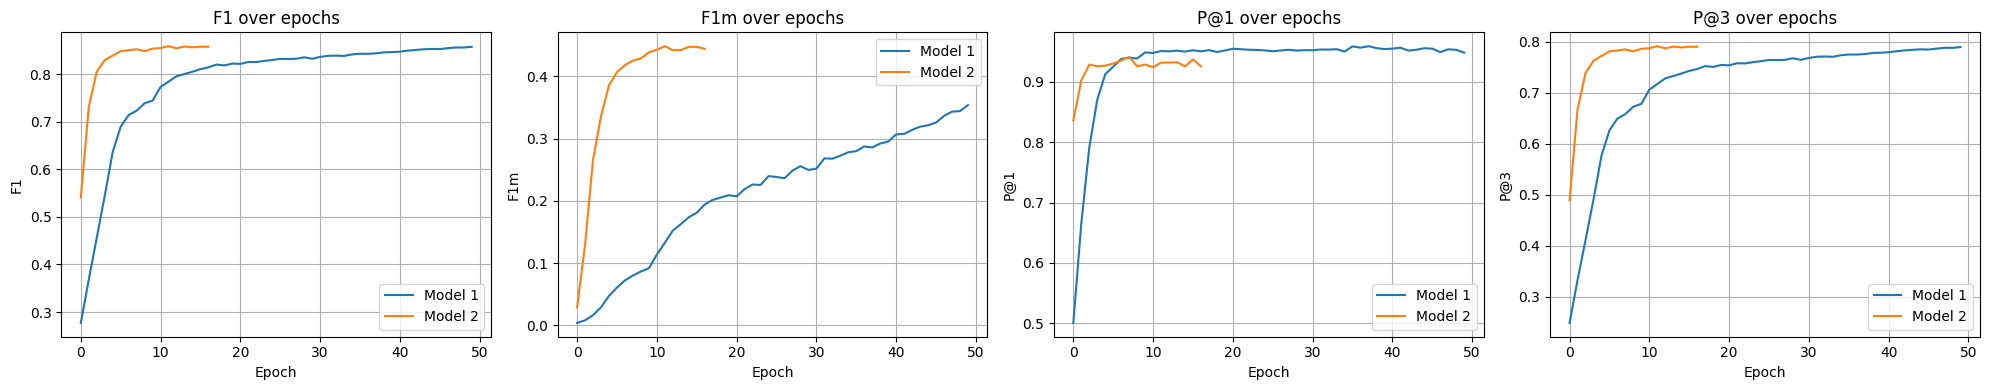

In [18]:
results = {
    "F1": {
        "Model 1": f1_curve,
        "Model 2": f1_curve2,
    },
    "F1m": {
        "Model 1": f1m_curve,
        "Model 2": f1m_curve2,
    },
    "P@1": {
        "Model 1": p1_curve,
        "Model 2": p1_curve2,
    },
    "P@3": {
        "Model 1": p3_curve,
        "Model 2": p3_curve2,
    }
}

print("\nGraph")
plot_all_metrics(results)

In [ ]:
# Function selecting 2 or 3 labels
def select_k(prob, min_k=2, max_k=3):
    idx = np.argsort(prob)[::-1]
    top3 = idx[:max_k]
    if prob[top3[2]] < 0.50 * prob[top3[1]]:
        return top3[:2]
    return top3

In [20]:
# Submission step

print("Test count:", len(test_ids))

# Eval mode
model.eval()

preds = []
batch_size = 64

with torch.no_grad():
    for b_start in tqdm(range(0, len(test_ids), batch_size)):
        batch_pids = test_ids[b_start:b_start + batch_size]

        batch_emb = torch.stack([X_all[pid2idx[pid]] for pid in batch_pids]).to(device)

        logits = model(batch_emb)
        probs = torch.sigmoid(logits).cpu().numpy()

        for p in probs:
            labels = select_k(p)
            preds.append([str(x) for x in labels])


# Save submission
OUT_DIR = Path("Submission")
OUT_DIR.mkdir(exist_ok=True)
OUT_PATH = OUT_DIR / "submission_gnn_reg.csv"

with open(OUT_PATH, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["id", "label"])
    for pid, labels in zip(test_ids, preds):
        true_test_id = pid - n_train
        w.writerow([true_test_id, ",".join(labels)])

print(f"Submission saved -> {OUT_PATH}")

LABEL_EMB_PATH = "SilverGeneration/Embeddings/label_emb_gnn_reg.pt"
torch.save(model.label_emb.detach().cpu(), LABEL_EMB_PATH)
print(f"Label embeddings saved : {LABEL_EMB_PATH}")


Test count: 19658


100%|██████████| 308/308 [00:01<00:00, 305.22it/s]

Submission saved -> Submission\submission_gnn_reg.csv
Label embeddings saved : SilverGeneration/Embeddings/label_emb_gnn_reg.pt


In [ ]:
# Submission step

print("Test count:", len(test_ids))

# Function selecting 2 or 3 labels
def select_k(prob, min_k=2, max_k=3):
    idx = np.argsort(prob)[::-1]
    top3 = idx[:max_k]
    if prob[top3[2]] < 0.50 * prob[top3[1]]:
        return top3[:2]
    return top3

# Eval mode
model2.eval()

preds = []
batch_size = 64

with torch.no_grad():
    for b_start in tqdm(range(0, len(test_ids), batch_size)):
        batch_pids = test_ids[b_start:b_start + batch_size]

        batch_emb = torch.stack([X_all[pid2idx[pid]] for pid in batch_pids]).to(device)

        logits = model2(batch_emb)
        probs = torch.sigmoid(logits).cpu().numpy()

        for p in probs:
            labels = select_k(p)
            preds.append([str(x) for x in labels])


# Save submission
OUT_DIR = Path("Submission")
OUT_DIR.mkdir(exist_ok=True)
OUT_PATH = OUT_DIR / "submission_gnn.csv"

with open(OUT_PATH, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["id", "label"])
    for pid, labels in zip(test_ids, preds):
        true_test_id = pid - n_train
        w.writerow([true_test_id, ",".join(labels)])

print(f"Submission saved -> {OUT_PATH}")

LABEL_EMB_PATH = "SilverGeneration/Embeddings/label_emb_gnn.pt"
torch.save(save_model.label_emb.detach().cpu(), LABEL_EMB_PATH)
print(f"Label embeddings saved → {LABEL_EMB_PATH}")

Test count: 19658


100%|██████████| 308/308 [00:00<00:00, 332.85it/s]

Submission saved -> Submission\submission_gnn.csv
Label embeddings saved → SilverGeneration/Embeddings/label_emb_gnn.pt


In [22]:
# Comparison with real results

def load_csv_labels(path):
    """
    Load a CSV file formatted as:
    id,label1 label2 label3
    Returns {id: [labels]}
    """
    out = {}
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            pid = int(row["id"])
            labels = [int(x) for x in row["label"].replace(",", " ").split()]
            out[pid] = labels
    return out


def score_submission_csv(pred_path, gold_path):
    """
    Score a submission CSV using your GOLD CSV.
    Computes: F1 (samples), P@1, P@3
    """
    pred = load_csv_labels(pred_path)
    gold = load_csv_labels(gold_path)

    # Sorted IDs intersection
    ids = sorted(set(pred.keys()) & set(gold.keys()))

    num_classes = 531

    Y_true = []
    Y_pred = []
    Y_scores = []

    for pid in ids:
        true_vec  = np.zeros(num_classes)
        pred_vec  = np.zeros(num_classes)
        score_vec = np.zeros(num_classes)

        true_vec[gold[pid]] = 1
        pred_vec[pred[pid]] = 1
        score_vec[pred[pid]] = 1.0

        Y_true.append(true_vec)
        Y_pred.append(pred_vec)
        Y_scores.append(score_vec)

    f1s = f1_score(Y_true, Y_pred, average="samples")
    P1 = precision_at_1(Y_true, Y_scores)
    P3 = precision_at_3(Y_true, Y_scores)

    print(f"Sample F1 : {f1s:.4f}")
    print(f"P@1 : {P1:.2f}")
    print(f"P@3 : {P3:.2f}")

score_submission_csv(
    pred_path="Submission/submission_gnn.csv",
    gold_path="Gold/gold.csv"
)

score_submission_csv(
    pred_path="Submission/submission_gnn_reg.csv",
    gold_path="Gold/gold.csv"
)

Sample F1 : 0.5600
P@1 : 0.80
P@3 : 0.53
Sample F1 : 0.5600
P@1 : 0.80
P@3 : 0.53


In [23]:
CLASS_HIERARCHY_PATH = ROOT / "class_hierarchy.txt"

def load_multilabel(path):
    """Load multi-label data into {id: [labels]} dictionary -> for class_hierarchy"""
    id2labels = {}
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 2:
                pid, label = parts
                pid = int(pid)
                label = int(label)
                if pid not in id2labels:
                    id2labels[pid] = []
                id2labels[pid].append(label)
    return id2labels
    
class2hierarchy = load_multilabel(CLASS_HIERARCHY_PATH)

pairs = []
for parent, children in class2hierarchy.items():
    for c in children:
        pairs.append((parent, c))

# roots
parents = set(p for p, c in pairs)
children = set(c for p, c in pairs)
roots = sorted(parents - children)

print(roots)

def load_parent_map(path):
    """
    Returns:
        parent_map = {parent: [child1, child2, ...]}
    """
    parent_map = {}

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parent, child = line.strip().split("\t")
            parent = int(parent)
            child = int(child)

            if parent not in parent_map:
                parent_map[parent] = []
            parent_map[parent].append(child)

    return parent_map

parents_map = {i: [] for i in range(n_classes)}
children_map = {i: [] for i in range(n_classes)}

with open(CLASS_HIERARCHY_PATH, "r") as f:
    for line in f:
        p, c = map(int, line.strip().split("\t"))
        parents_map[c].append(p)  
        children_map[p].append(c)    
print("Parents of 1:", parents_map[1])
print("Children of 0:", children_map[0])

#label_init_emb = torch.load("SilverGeneration/Embeddings/label_emb_gnn_reg.pt").to(device)


[0, 3, 10, 23, 40, 169]
Parents of 1: [0]
Children of 0: [1, 8, 208, 211, 213, 216, 229, 255, 265, 218, 271, 277, 249, 288, 313, 357]


In [24]:
def get_full_hierarchy(label, parents_map, children_map):
    hset = set([label])

    # UPWARD: find all ancestors
    stack = [label]
    while stack:
        node = stack.pop()
        parents = parents_map.get(node, [])
        for p in parents:
            if p not in hset:
                hset.add(p)
                stack.append(p)

    # DOWNWARD: find all descendants
    stack = [label]
    while stack:
        node = stack.pop()
        children = children_map.get(node, [])
        for ch in children:
            if ch not in hset:
                hset.add(ch)
                stack.append(ch)

    return hset


In [25]:
print("\nSelf Training -> Silver Generation Filtering")

ROOT_CLASSES = {0, 3, 10, 23, 40, 169}

model.eval()
with torch.no_grad():
    logits_train = model(X_all)
    probs_train = torch.sigmoid(logits_train).cpu().numpy()

new_silver = {}
MIN_CONF = 0.65

for pid in all_ids:
    idx = pid2idx[pid]
    prob = probs_train[idx]

    # Top confident predictions
    top = prob.argsort()[::-1][:10]
    pred_labels = [int(c) for c in top if prob[c] >= MIN_CONF]

    pred_scores = [float(prob[c]) for c in pred_labels]

    new_silver[pid] = {
        "labels": pred_labels,
        "scores": pred_scores
    }

# CLEANUP
final_clean = {}

for pid, data in new_silver.items():

    labels = data["labels"]
    scores = data["scores"]

    # Remove low-confidence labels
    cleaned_labels = []
    cleaned_scores = []
    for c, s in zip(labels, scores):
        if s >= MIN_CONF:
            cleaned_labels.append(int(c))
            cleaned_scores.append(float(s))

    # If empty skip
    if not cleaned_labels:
        continue

    # Keep only hierarchy of best label
    best_label = cleaned_labels[np.argmax(cleaned_scores)]
    allowed = get_full_hierarchy(best_label, parents_map, children_map)

    filtered_labels = []
    filtered_scores = []
    for c, s in zip(cleaned_labels, cleaned_scores):
        if c in allowed:
            filtered_labels.append(int(c))
            filtered_scores.append(float(s))

    # Remove solo predictions
    if len(filtered_labels) <= 1:
        continue

    final_clean[pid] = {
        "labels": filtered_labels,
        "scores": filtered_scores
    }

final_filtered = {
    pid: data
    for pid, data in final_clean.items()
}

print("New hierarchical pseudo-labels generated")
print("Remaining samples:", len(final_filtered))

out_path = "SilverGeneration/Silver/silver_train_refinement_gnn.json"
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(final_filtered, f, indent=2)

print(f"Saved refined pseudo-labels : {out_path}")



Self Training -> Silver Generation Filtering
New hierarchical pseudo-labels generated
Remaining samples: 11748
Saved refined pseudo-labels : SilverGeneration/Silver/silver_train_refinement_gnn.json


In [26]:
class UnlabeledEmbeddingDataset(Dataset):
    def __init__(self, pids):
        self.pids = pids

    def __len__(self):
        return len(self.pids)

    def __getitem__(self, idx):
        pid = self.pids[idx]
        emb = X_all[pid2idx[pid]]
        return {"X": emb, "pid": pid}


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from collections import Counter

def tsne_visualize(X_all, all_ids, current_labels, current_scores, TOP_K=20, N=4000):
    """
    Reproduce EXACT t-SNE visualization pipeline you executed earlier.
    Same ROOT_SET, colors, mapping, filtering, style.
    """
    refined = {
        pid: {"labels": labs, "scores": current_scores[pid]}
        for pid, labs in current_labels.items()
    }

    X = X_all.cpu().numpy()
    idx = np.random.choice(len(X), size=min(N, len(X)), replace=False)
    X_sub = X[idx]
    ids_subset = np.array(all_ids)[idx]

    ROOT_SET = {0, 3, 10, 23, 40, 169}

    leaf_labels = []
    root_labels = []

    for pid in ids_subset:
        entry = refined.get(pid)

        if entry:
            labs = entry["labels"]
            leaf = labs[0]
            root = next((x for x in labs if x in ROOT_SET), -1)
        else:
            leaf = root = -1

        leaf_labels.append(leaf)
        root_labels.append(root)

    leaf_labels = np.array(leaf_labels)
    root_labels = np.array(root_labels)

    cnt = Counter(leaf_labels[leaf_labels >= 0])
    top_leafs = set([lab for lab, _ in cnt.most_common(TOP_K)])

    print(f"Top-{TOP_K} leaf classes:", cnt.most_common(TOP_K))

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_emb = tsne.fit_transform(X_sub)

    plt.figure(figsize=(10, 8))

    mask_other = np.array([l not in top_leafs for l in leaf_labels])
    mask_top = ~mask_other

    # Others in light gray
    plt.scatter(X_emb[mask_other,0], X_emb[mask_other,1],
                s=5, alpha=0.15, color="lightgray", label="Other classes")

    # Remapping TOP-K into compact range
    unique_top = sorted(top_leafs)
    mapping = {lab: i for i, lab in enumerate(unique_top)}
    compact = np.array([mapping.get(l, -1) for l in leaf_labels])

    # TOP-K in tab20 (same style as before)
    plt.scatter(X_emb[mask_top,0], X_emb[mask_top,1],
                s=12, c=compact[mask_top], cmap="tab20",
                label=f"Top {TOP_K} leaf classes")

    plt.title(f"t-SNE — Top-{TOP_K} most represented leaf classes")
    plt.legend()
    plt.show()

    print("TSNE visualization completed.")

In [28]:
# Load refined silver labels
with open("SilverGeneration/Silver/silver_train_refinement_gnn.json", "r", encoding="utf-8") as f:
    raw2 = json.load(f)

new_silver_labels = {int(pid): data["labels"] for pid, data in raw2.items()}
new_silver_scores = {int(pid): data["scores"] for pid, data in raw2.items()}

print("Loaded refined silver samples:", len(new_silver_labels))

all_train_ids = list(new_silver_labels.keys())
print(all_train_ids)
val_ratio = 0.15

train_ids, val_ids = train_test_split(all_train_ids, test_size=val_ratio, random_state=42)

print("Train IDs:", len(train_ids))
print("Val IDs:", len(val_ids))

silver_ids = [pid for pid in new_silver_labels if pid in train_ids]

print("Silvers in train:", len(silver_ids))

current_labels = {pid: new_silver_labels[pid] for pid in silver_ids}
current_scores = {pid: new_silver_scores[pid] for pid in silver_ids}

unlabeled_set = set(train_ids) - set(silver_ids)

print("Initial labeled:", len(current_labels))

train_dataset = MultiLabelDataset(list(current_labels.keys()), current_labels, current_scores, n_classes)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = MultiLabelDataset(val_ids, new_silver_labels, new_silver_scores, n_classes)
val_loader = DataLoader(val_dataset, batch_size=64)

print(len(val_dataset))

print("Total IDs:", len(all_ids))

# Count labeled vs unlabeled
unlabeled_count = len(all_ids) - len(new_silver_labels)
print("Unlabeled:", unlabeled_count)

pid_set = set(new_silver_labels.keys())
print("PID set size:", len(pid_set))

missing = set(all_ids) - pid_set
print("Missing PIDs:", missing)

unlabeled_pid = list(missing)

print("Unlabeled count:", len(unlabeled_pid))

all_train_ids = list(range(n_train))

Loaded refined silver samples: 11748
[2, 5, 6, 11, 14, 24, 32, 33, 35, 38, 43, 44, 57, 61, 63, 64, 69, 70, 75, 76, 79, 88, 90, 91, 92, 96, 98, 102, 104, 112, 115, 123, 125, 128, 131, 133, 134, 142, 156, 161, 163, 165, 170, 176, 197, 222, 226, 231, 232, 234, 236, 241, 244, 245, 254, 260, 261, 269, 270, 276, 278, 281, 288, 291, 292, 297, 305, 308, 311, 314, 319, 329, 332, 335, 339, 343, 346, 348, 349, 350, 365, 373, 397, 399, 403, 404, 406, 411, 414, 428, 430, 435, 439, 440, 441, 449, 456, 458, 467, 481, 486, 491, 492, 499, 509, 514, 518, 519, 523, 538, 540, 542, 543, 544, 545, 547, 548, 554, 560, 562, 563, 566, 568, 569, 571, 577, 582, 588, 592, 594, 596, 599, 619, 624, 633, 640, 641, 643, 648, 649, 651, 667, 669, 676, 677, 679, 686, 688, 689, 691, 693, 695, 698, 700, 702, 704, 709, 715, 718, 720, 721, 724, 728, 731, 736, 740, 741, 743, 744, 748, 753, 755, 756, 759, 764, 771, 773, 786, 787, 790, 794, 796, 801, 804, 806, 810, 814, 824, 828, 830, 840, 847, 852, 858, 859, 861, 863, 865, 87

In [29]:
# Regularization soft

dropout = 0.3

lambda_cons_max = 7.5

epochs = 50
noise_std = 0.05     

warmup = 10        
warmup_consistency = 10  
patience = 15          
alpha_ema = 0.90         

pseudo_update_freq = 5 
min_threshold = 0.5
max_threshold = 0.8
thr_step = (max_threshold - min_threshold) / epochs
MAX_PSEUDO_PER_UPDATE = 3000  


student = GCNEnhancedClassifierUpgrade(input_dim=X_all.size(1),label_init_emb=label_emb,A_hat=A_hat, parents_map=parents_map, num_layers=2,dropout=0.3,scale=25).to(device)
teacher = GCNEnhancedClassifierUpgrade(input_dim=X_all.size(1),label_init_emb=label_emb,A_hat=A_hat, parents_map=parents_map, num_layers=2,dropout=0.0, scale=25).to(device)
optimizer = torch.optim.Adam([{"params": student.proj.parameters(), "lr": 1e-3},{"params": student.encoder.parameters(), "lr": 2e-4},{"params": student.label_emb, "lr": 2e-4},])

teacher.load_state_dict(student.state_dict())

initial_silver_pids = set(current_labels.keys())
unlabeled_set = set(all_ids) - set(val_ids) - set(train_ids)

print(f"Initial labeled: {len(current_labels)}")
print(f"Initial val: {len(val_dataset)}")
print(f"Initial unlabeled: {len(unlabeled_set)}")

best_f1 = 0.0
best_state = None
wait = 0
drop_prob = 0.05
freeze_epochs = 5

Initial labeled: 9985
Initial val: 1763
Initial unlabeled: 37397


Top-20 leaf classes: [(220, 72), (40, 48), (169, 37), (43, 35), (49, 28), (93, 27), (199, 27), (4, 27), (170, 27), (3, 23), (44, 23), (15, 21), (8, 16), (131, 16), (32, 15), (26, 13), (129, 12), (21, 12), (41, 11), (206, 11)]


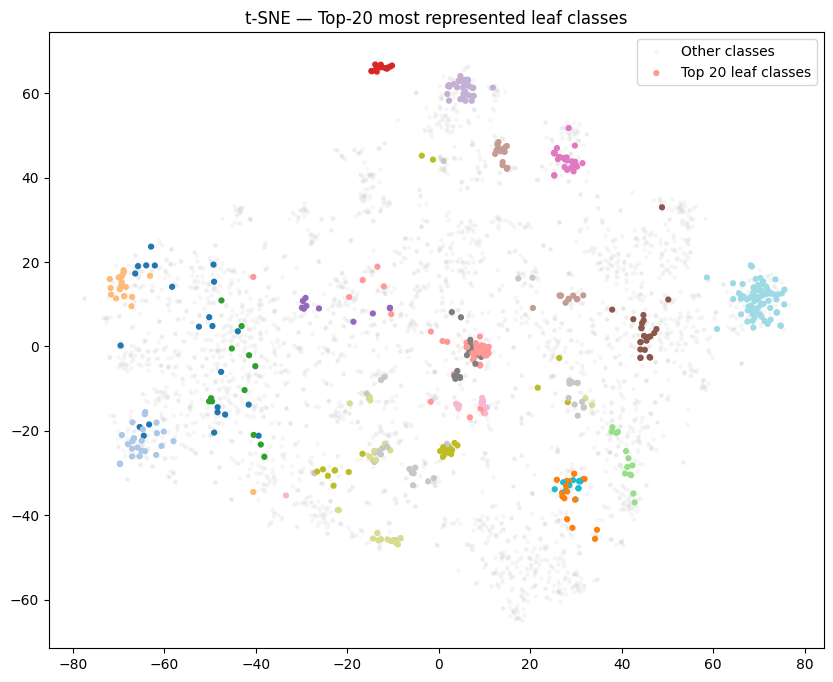

TSNE visualization completed.


In [30]:
tsne_visualize(X_all, all_ids, current_labels, current_scores)


In [ ]:
l1 = []
l2 = []
l3 = []
l4 = []

for epoch in range(1, epochs + 1):

    student.train()
    total_loss = 0.0
    total_sup_loss = 0.0
    total_loss_sep = 0.0
    total_hier_loss = 0.0
    total_cons_loss = 0.0
    num_cons_batches = 0

    if epoch <= freeze_epochs:
        student.label_emb.requires_grad_(False)
    else:
        student.label_emb.requires_grad_(True)

    train_pids = list(current_labels.keys())
    train_dataset = MultiLabelDataset(train_pids, current_labels, current_scores, n_classes)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    # UNLABELED loader
    if len(unlabeled_set) > 0:
        unlabeled_dataset = UnlabeledEmbeddingDataset(list(unlabeled_set))
        unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=64, shuffle=True)
        unlabeled_iter = iter(unlabeled_loader) #synchronization

    # Dynamic threshold et lambda_cons progressif
    threshold = min(max_threshold, min_threshold + thr_step * epoch)
    
    if epoch <= warmup_consistency:
        lambda_cons = 0.0
    else:
        progress = (epoch - warmup_consistency) / (epochs - warmup_consistency)
        lambda_cons = lambda_cons_max

    print(f"EPOCH {epoch}/{epochs}")
    print(f"Threshold: {threshold:.3f} | lambda_cons: {lambda_cons:.3f}")
    print(f"Labeled: {len(current_labels)} | Unlabeled: {len(unlabeled_set)}")


    for batch_l in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):

        X_l = batch_l["X"].to(device)
        y_l = batch_l["y"].to(device)
        
        mask = (torch.rand_like(y_l) > drop_prob).float()
        y_ld = y_l * mask

        smooth = dynamic_smoothing(epoch, epochs, 0.0, 0.0)
        y_smooth = y_ld * (1 - smooth) + smooth * 0.5

        # Supervised loss
        logits_s_l = student(X_l)
        sup_loss = F.binary_cross_entropy_with_logits(logits_s_l, y_smooth)
        hier_loss = hierarchical_parent_loss_fast(logits_s_l, parent_idx, child_idx, alpha=100.0) * 5

        loss = sup_loss + hier_loss

        total_sup_loss += sup_loss.item()
        total_hier_loss += hier_loss.item()

        cons_loss_val = 0.0

        # Consistency loss 
        if epoch > warmup_consistency and len(unlabeled_set) > 0 and lambda_cons > 0:

            try:
                batch_u = next(unlabeled_iter)
            except:
                unlabeled_iter = iter(unlabeled_loader)
                batch_u = next(unlabeled_iter)

            X_u = batch_u["X"].to(device)

            with torch.no_grad():
                logits_t = teacher(X_u)
                pseudo = torch.sigmoid(logits_t)

            noise = torch.randn_like(X_u) * noise_std
            logits_s_u = student(X_u + noise)
            probs_s = torch.sigmoid(logits_s_u)

            cons_loss = torch.mean((probs_s - pseudo) ** 2)
            hier_loss_u = hierarchical_parent_loss_fast(logits_s_u, parent_idx, child_idx, alpha=100.0) * 5
    
            loss = loss + lambda_cons * cons_loss + hier_loss_u

            cons_loss_val = cons_loss.item()
            total_cons_loss += cons_loss_val    
            num_cons_batches += 1          

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(student.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()


    # EMA teacher update
    for t, s in zip(teacher.parameters(), student.parameters()):
        t.data = alpha_ema * t.data + (1 - alpha_ema) * s.data


    # Validation
    teacher.eval()
    f1s, f1m, p1, p3 = evaluate_topk_full(teacher, val_loader)
    l1.append(f1s)
    l2.append(f1m)
    l3.append(p1)
    l4.append(p3)
    
    num_batches = len(train_loader)
    avg_total = total_loss / num_batches
    avg_sup = total_sup_loss / num_batches
    avg_hier = total_hier_loss / num_batches
    avg_cons = total_cons_loss / max(num_cons_batches, 1)

    print(f"\nLOSSES:")
    print(f"Total: {avg_total:.4f}")
    print(f"Sup: {avg_sup:.4f} ({avg_sup/avg_total*100:.1f}%)")
    print(f"Hier: {avg_hier:.4f} ({avg_hier/avg_total*100:.1f}%)")
    if num_cons_batches > 0:
        cons_contribution = (avg_cons * lambda_cons)
        print(f"Cons: {avg_cons:.4f} × {lambda_cons:.2f} = {cons_contribution:.4f} ({cons_contribution/avg_total*100:.1f}%)")

    # Early stopping
    if f1m > best_f1:
        best_f1 = f1m
        wait = 0
        best_state = teacher.state_dict()
        torch.save(best_state, MODEL_PATH)
        print(f"New best model (F1m={best_f1:.4f})")
    else:
        wait += 1
        print(f"No improvement ({wait}/{patience})")
        if wait >= patience:
            print(f"\nEarly stopping triggered")
            break

    # Pseudo label update
    if (epoch % pseudo_update_freq == 0 and epoch > warmup and len(unlabeled_set) > 0):

        teacher.eval()
        with torch.no_grad():
            logits_all = teacher(X_all.to(device))
            probs_all = torch.sigmoid(logits_all).cpu().numpy()

        new_pseudos = {}
        added = 0
        confidence_sum = 0.0
        num_with_parents = 0

        for pid in tqdm(list(unlabeled_set), desc="Pseudo-labeling", leave=False):

            if added >= MAX_PSEUDO_PER_UPDATE:
                break

            idx = pid2idx[pid]
            prob = probs_all[idx]

            # Top-2 confident leaf predictions 
            topk_idx = np.argpartition(prob, -2)[-2:]  
            topk_idx = topk_idx[np.argsort(prob[topk_idx])[::-1]]  
            topk_vals = prob[topk_idx]

            labels = []
            scores = []

            for cls, sc in zip(topk_idx.tolist(), topk_vals.tolist()):
                if sc >= threshold:
                    labels.append(int(cls))
                    scores.append(float(sc))

            # skip if no confident
            if len(labels) == 0:
                continue

            # hier add
            parent_threshold = threshold / 1.5

            final_labels = labels[:]
            final_scores = scores[:]

            for cls in labels:
                parents = parents_map.get(cls, [])

                # Force parents to list
                if isinstance(parents, int):
                    parents = [parents]

                for p in parents:
                    if prob[p] >= parent_threshold:
                        final_labels.append(int(p))
                        final_scores.append(float(prob[p]))

            new_pseudos[pid] = {
                "labels": final_labels,
                "scores": final_scores
            }

            added += 1

        for pid, d in new_pseudos.items():
            current_labels[pid] = d["labels"]
            current_scores[pid] = d["scores"]
            if pid in unlabeled_set:
                unlabeled_set.remove(pid)

        avg_conf = confidence_sum / max(added, 1)
        print(f"  Added: {len(new_pseudos)} pseudo-labels")
        print(f"  Remaining unlabeled: {len(unlabeled_set)}")

if best_state is not None:
    teacher.load_state_dict(best_state)
    print(f"Best F1m: {best_f1:.4f}")

teacher.eval()
with torch.no_grad():
    E_refine = teacher.encoder(teacher.label_emb, teacher.A_hat)
    E_norm = F.normalize(E_refine, dim=1)
    
    improvements = []
    print("\nParent-Child Cosine Similarities:")
    for i, (child, parents) in enumerate(parents_map.items()):
        if len(parents) > 0 and i < 10:
            parent = parents[0]
            sim = (E_norm[child] @ E_norm[parent]).item()
            improvements.append(sim)
    
    avg_hier = sum(improvements) / len(improvements)
    print(f"\nAverage parent-child: {avg_hier:.3f}")
    
    # Random baseline
    random_sims = []
    for _ in range(2000):
        i, j = torch.randint(0, len(E_norm), (2,))
        if i != j:
            random_sims.append((E_norm[i] @ E_norm[j]).item())
    
    avg_random = sum(random_sims) / len(random_sims)
    print(f"Average random pairs: {avg_random:.3f}")
    print(f"Hierarchy boost: {avg_hier - avg_random:+.3f}")


EPOCH 1/50
Threshold: 0.506 | lambda_cons: 0.000
Labeled: 9985 | Unlabeled: 37397



LOSSES:
Total: 0.0219
Sup: 0.0202 (92.2%)
Hier: 0.0017 (7.8%)
New best model (F1m=0.0066)

EPOCH 2/50
Threshold: 0.512 | lambda_cons: 0.000
Labeled: 9985 | Unlabeled: 37397



LOSSES:
Total: 0.0130
Sup: 0.0128 (98.2%)
Hier: 0.0002 (1.8%)
New best model (F1m=0.0158)

EPOCH 3/50
Threshold: 0.518 | lambda_cons: 0.000
Labeled: 9985 | Unlabeled: 37397



LOSSES:
Total: 0.0110
Sup: 0.0107 (97.2%)
Hier: 0.0003 (2.8%)
New best model (F1m=0.0255)

EPOCH 4/50
Threshold: 0.524 | lambda_cons: 0.000
Labeled: 9985 | Unlabeled: 37397



LOSSES:
Total: 0.0099
Sup: 0.0096 (96.7%)
Hier: 0.0003 (3.3%)
New best model (F1m=0.0260)

EPOCH 5/50
Threshold: 0.530 | lambda_cons: 0.000
Labeled: 9985 | Unlabeled: 37397


...


LOSSES:
Total: 0.0045
Sup: 0.0035 (77.7%)
Hier: 0.0000 (0.3%)
Cons: 0.0001 × 7.50 = 0.0009 (20.8%)
No improvement (4/15)

EPOCH 48/50
Threshold: 0.788 | lambda_cons: 7.500
Labeled: 20446 | Unlabeled: 26936



LOSSES:
Total: 0.0045
Sup: 0.0035 (77.5%)
Hier: 0.0000 (0.3%)
Cons: 0.0001 × 7.50 = 0.0009 (20.9%)
No improvement (5/15)

EPOCH 49/50
Threshold: 0.794 | lambda_cons: 7.500
Labeled: 20446 | Unlabeled: 26936



LOSSES:
Total: 0.0046
Sup: 0.0035 (77.0%)
Hier: 0.0000 (0.4%)
Cons: 0.0001 × 7.50 = 0.0010 (21.3%)
No improvement (6/15)

EPOCH 50/50
Threshold: 0.800 | lambda_cons: 7.500
Labeled: 20446 | Unlabeled: 26936



LOSSES:
Total: 0.0046
Sup: 0.0035 (76.9%)
Hier: 0.0000 (0.3%)
Cons: 0.0001 × 7.50 = 0.0010 (21.3%)
No improvement (7/15)


  Added: 1591 pseudo-labels
  Remaining unlabeled: 25345
Best F1m: 0.1635

Parent-Child Cosine Similarities:

Average parent-child: 0.856
Average random pairs: 0.656
Hierarchy boost: +0.199


In [32]:
print("Test count:", len(test_ids))
# Eval mode
teacher.eval()

preds = []
batch_size = 64

with torch.no_grad():
    for b_start in tqdm(range(0, len(test_ids), batch_size)):
        batch_pids = test_ids[b_start:b_start + batch_size]

        batch_emb = torch.stack([X_all[pid2idx[pid]] for pid in batch_pids]).to(device)

        logits = teacher(batch_emb)
        probs = torch.sigmoid(logits).cpu().numpy()

        for p in probs:
            labels = select_k(p)
            preds.append([str(x) for x in labels])


# Save submission
OUT_DIR = Path("Submission")
OUT_DIR.mkdir(exist_ok=True)
OUT_PATH = OUT_DIR / "submission_gnn_st.csv"

with open(OUT_PATH, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["id", "label"])
    for pid, labels in zip(test_ids, preds):
        true_test_id = pid - n_train
        w.writerow([true_test_id, ",".join(labels)])

print(f"Submission saved -> {OUT_PATH}")


Test count: 19658


100%|██████████| 308/308 [00:01<00:00, 289.86it/s]

Submission saved -> Submission\submission_gnn_st.csv


Top-20 leaf classes: [(3, 352), (169, 200), (40, 152), (10, 106), (220, 98), (0, 59), (170, 51), (4, 43), (43, 37), (8, 31), (23, 27), (131, 27), (49, 25), (32, 24), (199, 23), (15, 21), (24, 19), (11, 19), (64, 17), (93, 14)]


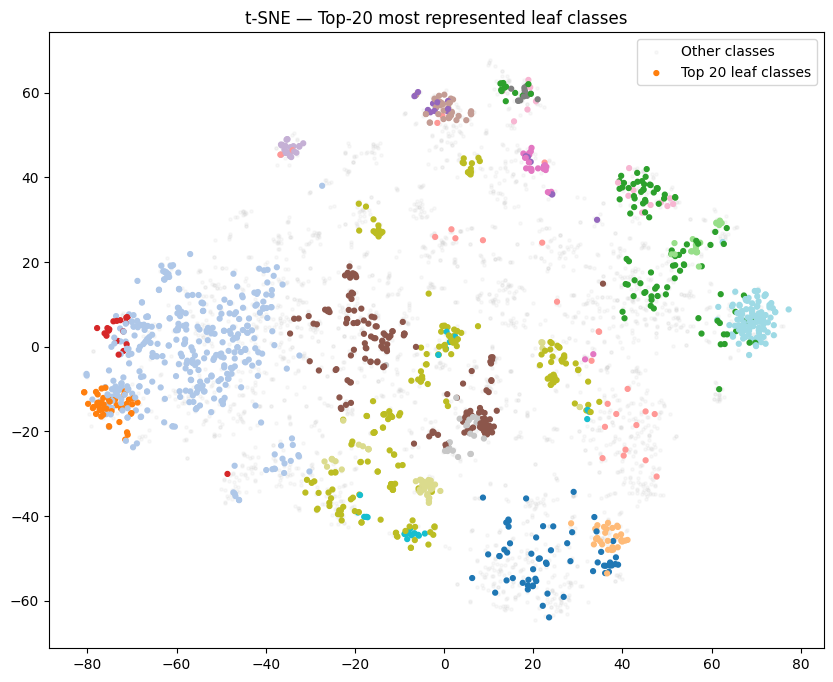

TSNE visualization completed.


In [33]:
tsne_visualize(X_all, all_ids, current_labels, current_scores)



Graph


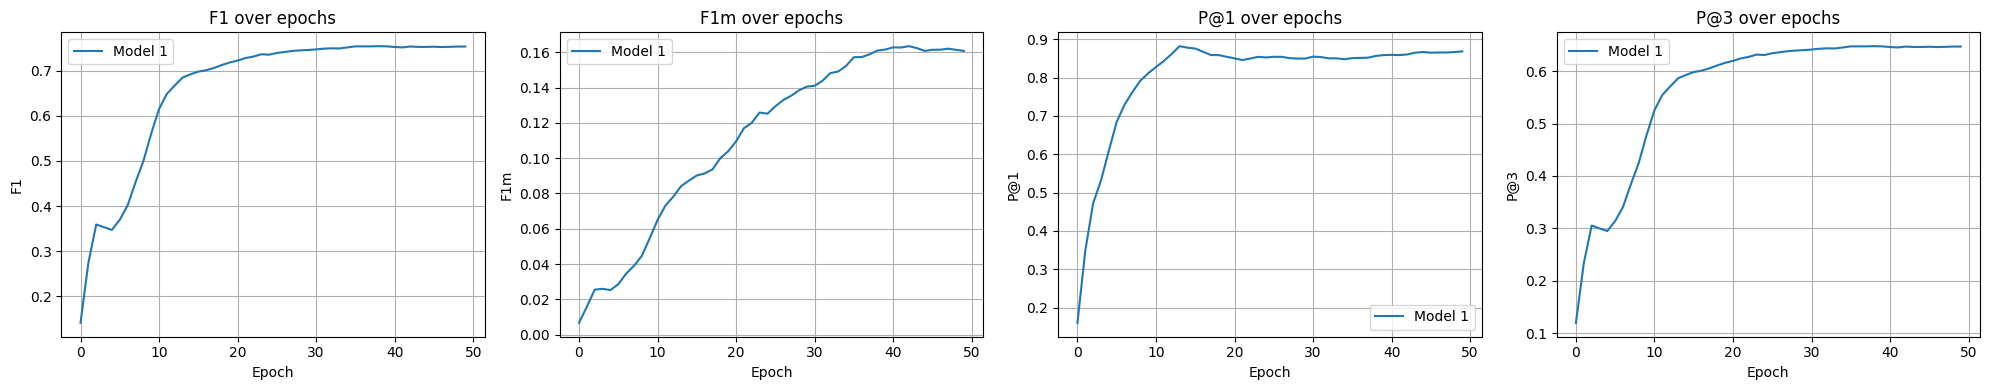

In [34]:
results = {
    "F1": {
        "Model 1": l1,
    },
    "F1m": {
        "Model 1": l2,
    },
    "P@1": {
        "Model 1": l3,
    },
    "P@3": {
        "Model 1": l4,
    }
}

print("\nGraph")
plot_all_metrics(results)

In [35]:
score_submission_csv(
    pred_path="Submission/submission_gnn_st.csv",
    gold_path="Gold/gold.csv"
)

Sample F1 : 0.5333
P@1 : 0.80
P@3 : 0.53
